# Submission for "PREPARE: Pioneering Research for Early Prediction of Alzheimer's and Related Dementias EUREKA Challenge"
## Examples


In [2]:
%load_ext autoreload
%autoreload 2

## Imports
See requirements.txt for the required versions.

In [4]:
import numpy as np
import pandas as pd

import shap
import matplotlib.pyplot as plt

from src.train import train
from src.predict import predict
from src.visualise import visualise_prediction, visualise_decision

## File paths

Update these to the appropriate places

In [6]:
# Raw data paths

train_features_path = '../data/raw/train_features.csv'
train_labels_path = '../data/raw/train_labels.csv'

test_features_path = '../data/raw/test_features.csv'
submission_format_path = '../data/raw/submission_format.csv'

# Where to save predictions, for submission and later analysis 

test_predictions_path =  '../data/processed/test_predictions.csv'
test_predictions_with_mapie_path =  '../data/processed/test_predictions_mapie.csv'

# Where to save model

model_save_path = '../models/model.pkl'

## Training


In [8]:
train(
    features_path = train_features_path,
    labels_path = train_labels_path,
    model_save_path = model_save_path,
);

2025-03-31 16:03:11.508 | INFO     | src.train:train:59 - Loading data from ../data/raw/train_features.csv, ../data/raw/train_labels.csv
2025-03-31 16:03:11.553 | INFO     | src.train:train:63 - Processing data. Data shape: features (3276, 184), labels (4343, 3)
2025-03-31 16:03:11.597 | INFO     | src.train:train:183 - Training ensemble
2025-03-31 16:03:28.297 | INFO     | src.train:train:188 - Training MAPIE regressor
2025-03-31 16:06:25.937 | SUCCESS  | src.train:train:212 - Trained models saved to ../models/model.pkl


## Basic prediction

In [10]:
labels, _, _ = predict(
    model_path = model_save_path,
    features_path = test_features_path,
    submission_save_path = test_predictions_path,
    submission_format_path = submission_format_path
)

2025-03-31 16:06:26.096 | INFO     | src.predict:predict:57 - Loading data from ../data/raw/test_features.csv, ../data/raw/submission_format.csv
2025-03-31 16:06:26.118 | INFO     | src.predict:predict:61 - Processing data. Data shape: features (819, 184), labels (1105, 3)
2025-03-31 16:06:26.145 | INFO     | src.predict:predict:72 - Loading trained model weights from ../models/model.pkl
2025-03-31 16:06:26.322 | INFO     | src.predict:predict:81 - Predicting labels
2025-03-31 16:06:26.397 | INFO     | src.predict:predict:106 - Calculating SHAP values
2025-03-31 16:06:29.089 | SUCCESS  | src.predict:predict:113 - Submission saved to ../data/processed/test_predictions.csv


In [11]:
labels.head(4)

,uid,year,composite_score
0,abxu,2016,163
1,aeol,2016,210
2,aeol,2021,206
3,afnb,2016,218


## Prediction with MAPIE intervals and SHAP explanations

In [13]:
labels, ensemble_explanation, subestimator_explanations = predict(
    model_path = model_save_path,
    features_path = test_features_path,
    submission_save_path = test_predictions_with_mapie_path,
    submission_format_path = submission_format_path,
    include_mapie = True,
    debug = False
)

2025-03-31 16:06:29.195 | INFO     | src.predict:predict:57 - Loading data from ../data/raw/test_features.csv, ../data/raw/submission_format.csv
2025-03-31 16:06:29.209 | INFO     | src.predict:predict:61 - Processing data. Data shape: features (819, 184), labels (1105, 3)
2025-03-31 16:06:29.231 | INFO     | src.predict:predict:72 - Loading trained model weights from ../models/model.pkl
2025-03-31 16:06:29.391 | INFO     | src.predict:predict:81 - Predicting labels
2025-03-31 16:06:29.462 | INFO     | src.predict:predict:95 - Predicting MAPIE intervals
2025-03-31 16:06:30.595 | INFO     | src.predict:predict:106 - Calculating SHAP values
2025-03-31 16:06:33.217 | SUCCESS  | src.predict:predict:113 - Submission saved to ../data/processed/test_predictions_mapie.csv


In [14]:
labels.head(4)

,uid,year,composite_score,mapie_lower_90,mapie_upper_90,mapie_lower_60,mapie_upper_60
0,abxu,2016,163,85,243,112,215
1,aeol,2016,210,130,287,157,259
2,aeol,2021,206,126,283,154,256
3,afnb,2016,218,136,293,164,265


## Outputs for explainer reports

### Indexes of the predictions to explain

In [17]:
explainer_indexes = [377, 1037, 216]

### General info

In [19]:
explainer_labels = labels.loc[explainer_indexes]
explainer_labels

,uid,year,composite_score,mapie_lower_90,mapie_upper_90,mapie_lower_60,mapie_upper_60
377,jepa,2021,48,-28,130,0,101
1037,yeeg,2021,107,29,187,57,159
216,fnfh,2016,200,120,277,147,249


In [20]:
# when we output, we can set 0 as the minimum value, e.g. for 377 mapie_lower_90

### Visualise prediction and prediction intervals against population


 jepa


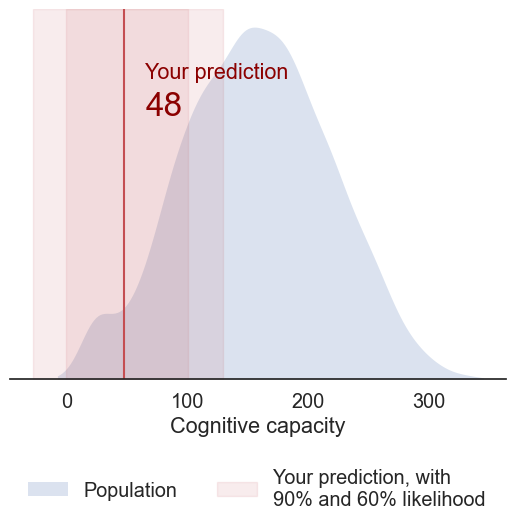


 yeeg


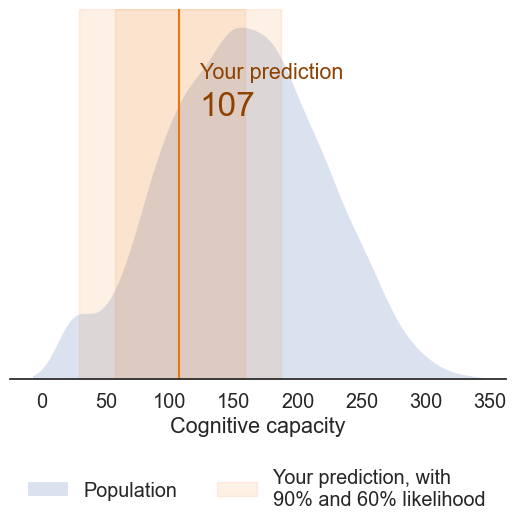


 fnfh


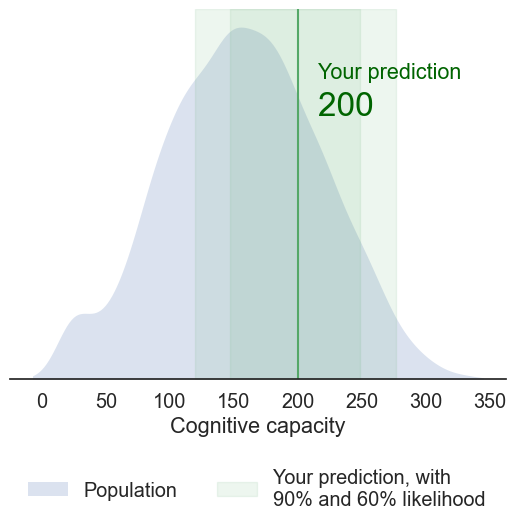

In [22]:
for i in explainer_indexes:
    label = labels.loc[i]
    print('\n', label['uid'])
    plt = visualise_prediction(label, train_labels_path, show=False)
    # Optionally customise, and save, embed or show the plot here
    plt.show()

### Visualise SHAP decision plots for the individual predictions


 jepa


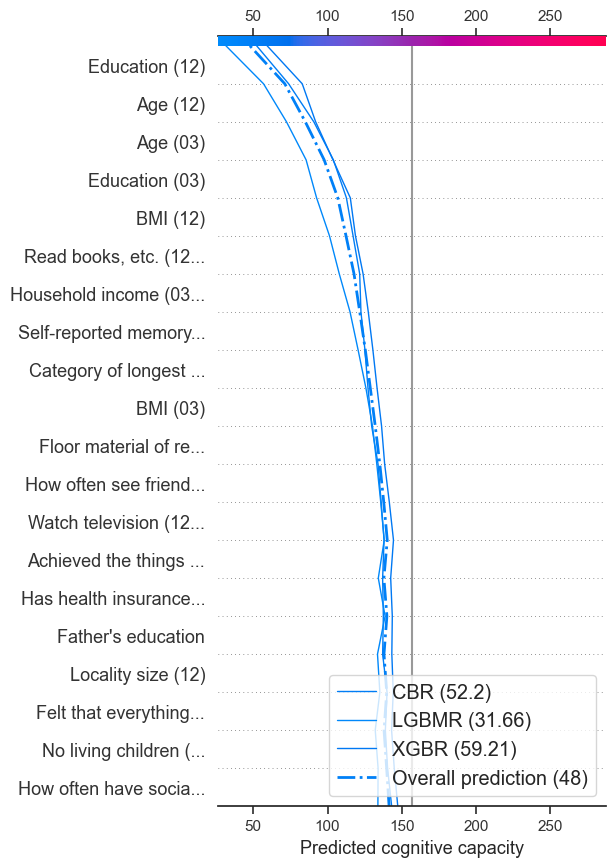


 yeeg


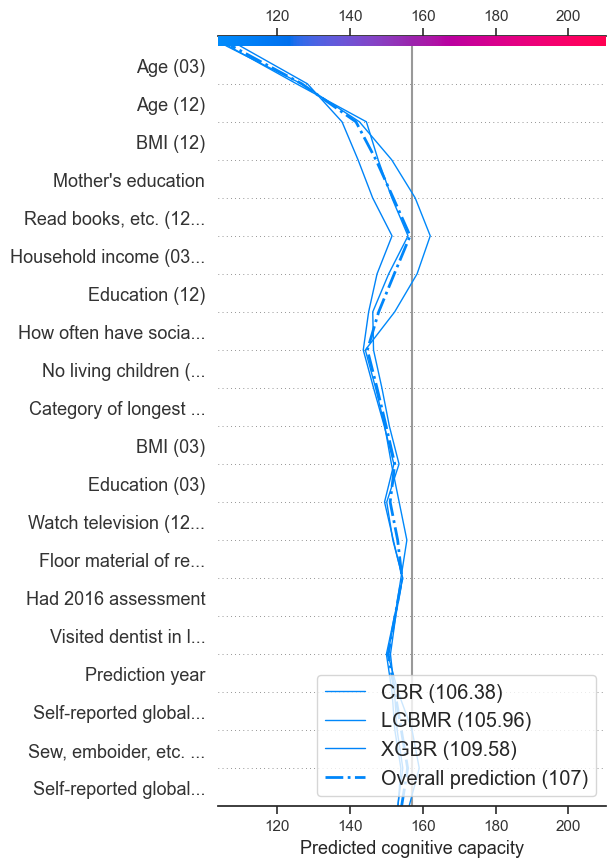


 fnfh


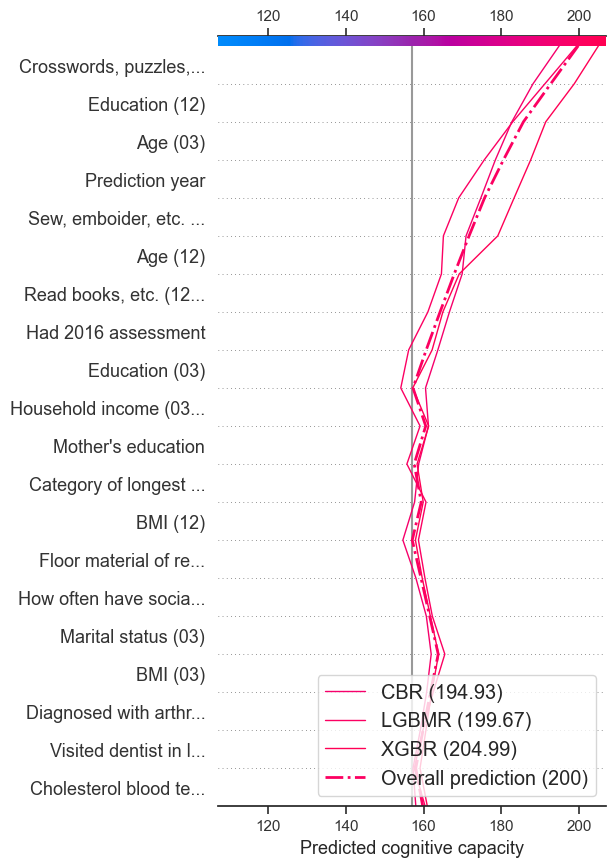

In [24]:
for i in explainer_indexes:
    print('\n', labels.loc[i, 'uid'])
    plt = visualise_decision(i, ensemble_explanation, subestimator_explanations, show=False)
    # Optionally customise, and save, embed or show the plot here
    plt.show()

## Using the SHAP Explainer objects

See https://shap.readthedocs.io/en/latest/index.html for more.

### Overall picture

In [27]:
# See overall SHAP values for each feature

feature_shap_values = np.mean(np.abs(ensemble_explanation.values), axis=0)
feature_shap_values = pd.DataFrame([feature_shap_values], columns=ensemble_explanation.feature_names)
with pd.option_context('display.max_columns', 200):
    display(feature_shap_values)

,age_03,urban_03,married_03,n_mar_03,edu_gru_03,n_living_child_03,migration_03,glob_hlth_03,adl_dress_03,adl_walk_03,adl_bath_03,adl_eat_03,adl_bed_03,adl_toilet_03,n_adl_03,iadl_money_03,iadl_meds_03,iadl_shop_03,iadl_meals_03,n_iadl_03,depressed_03,hard_03,restless_03,happy_03,lonely_03,enjoy_03,sad_03,tired_03,energetic_03,n_depr_03,cesd_depressed_03,hypertension_03,diabetes_03,resp_ill_03,arthritis_03,hrt_attack_03,stroke_03,cancer_03,n_illnesses_03,bmi_03,exer_3xwk_03,alcohol_03,tobacco_03,test_chol_03,test_tuber_03,test_diab_03,test_pres_03,hosp_03,visit_med_03,out_proc_03,visit_dental_03,imss_03,issste_03,pem_def_mar_03,insur_private_03,insur_other_03,insured_03,decis_famil_03,decis_personal_03,employment_03,age_12,urban_12,married_12,n_mar_12,edu_gru_12,n_living_child_12,migration_12,glob_hlth_12,adl_dress_12,adl_walk_12,adl_bath_12,adl_eat_12,adl_bed_12,adl_toilet_12,n_adl_12,iadl_money_12,iadl_meds_12,iadl_shop_12,iadl_meals_12,n_iadl_12,depressed_12,hard_12,restless_12,happy_12,lonely_12,enjoy_12,sad_12,tired_12,energetic_12,n_depr_12,cesd_depressed_12,hypertension_12,diabetes_12,resp_ill_12,arthritis_12,hrt_attack_12,stroke_12,cancer_12,n_illnesses_12,bmi_12,exer_3xwk_12,alcohol_12,tobacco_12,test_chol_12,test_tuber_12,test_diab_12,test_pres_12,hosp_12,visit_med_12,out_proc_12,visit_dental_12,imss_12,issste_12,pem_def_mar_12,insur_private_12,insur_other_12,insured_12,decis_famil_12,decis_personal_12,employment_12,vax_flu_12,vax_pneu_12,seg_pop_12,care_adult_12,care_child_12,volunteer_12,attends_class_12,attends_club_12,reads_12,games_12,table_games_12,comms_tel_comp_12,act_mant_12,tv_12,sewing_12,satis_ideal_12,satis_excel_12,satis_fine_12,cosas_imp_12,wouldnt_change_12,memory_12,ragender,rameduc_m,rafeduc_m,sgender_03,rjob_hrswk_03,rearnings_03,searnings_03,hincome_03,hinc_business_03,hinc_rent_03,hinc_assets_03,hinc_cap_03,rinc_pension_03,sinc_pension_03,rrelgimp_03,sgender_12,rjob_hrswk_12,rjlocc_m_12,rearnings_12,searnings_12,hincome_12,hinc_business_12,hinc_rent_12,hinc_assets_12,hinc_cap_12,rinc_pension_12,sinc_pension_12,rrelgimp_12,rrfcntx_m_12,rsocact_m_12,rrelgwk_12,a34_12,j11_12,16_assessment,21_assessment,03_survey,12_survey,year
0,4.317535,0.09968,0.359256,0.130489,4.692534,0.902792,0.28174,0.424029,0.012239,0.057307,0.015175,0.031814,0.032059,0.01974,0.038474,0.12494,0.005873,0.037749,0.008385,0.041046,0.349914,0.475056,0.288839,0.296925,0.158649,0.274801,0.162462,0.144669,0.221242,0.874026,0.055608,0.334266,0.046733,0.189165,0.143349,0.010391,0.013861,0.108983,0.328649,1.591496,0.274985,0.337171,0.156923,0.146463,0.264659,0.095102,0.233843,0.157429,0.195553,0.013089,0.87796,0.162425,0.21143,0.014591,0.05244,0.082811,0.682582,0.371178,0.302549,0.172239,6.075057,1.213583,0.330607,0.189612,15.710344,2.454628,0.199445,1.046615,0.13667,0.134922,0.030024,0.003775,0.017806,0.041725,0.087006,0.075938,0.036391,0.128005,0.084778,1.537379,0.234943,1.626894,0.278205,0.799367,0.313591,0.230478,0.148492,0.37511,0.725252,1.303863,0.029258,0.271129,1.411256,0.013732,0.621087,0.003299,0.088612,0.005122,0.510795,3.332843,0.360976,0.213378,0.17075,0.590223,0.126196,0.135814,0.44955,0.115381,0.084146,0.01388,0.24077,1.048817,0.036722,0.01518,0.022867,0.028434,0.040827,0.433063,0.755388,0.326738,0.355565,0.345387,0.396593,0.204589,1.081869,0.501768,0.060357,0.160683,4.255842,2.366184,0.948828,0.768951,0.266738,0.531878,2.799683,0.298577,0.504888,0.32255,1.326551,0.698088,0.997864,0.086432,2.047908,0.910569,0.341613,0.418516,0.457719,0.395257,2.579141,0.273209,0.038992,0.397889,0.629118,0.584169,0.592807,0.322303,0.199293,1.49046,3.788164,0.115656,0.612871,0.949377,0.122121,0.092954,0.042772,0.220116,0.472572,0.620202,0.584881,2.00249,2.129082,0.307324,0.258644,2.43384,3.143606,2.047715,0.019109,0.0,2.332378


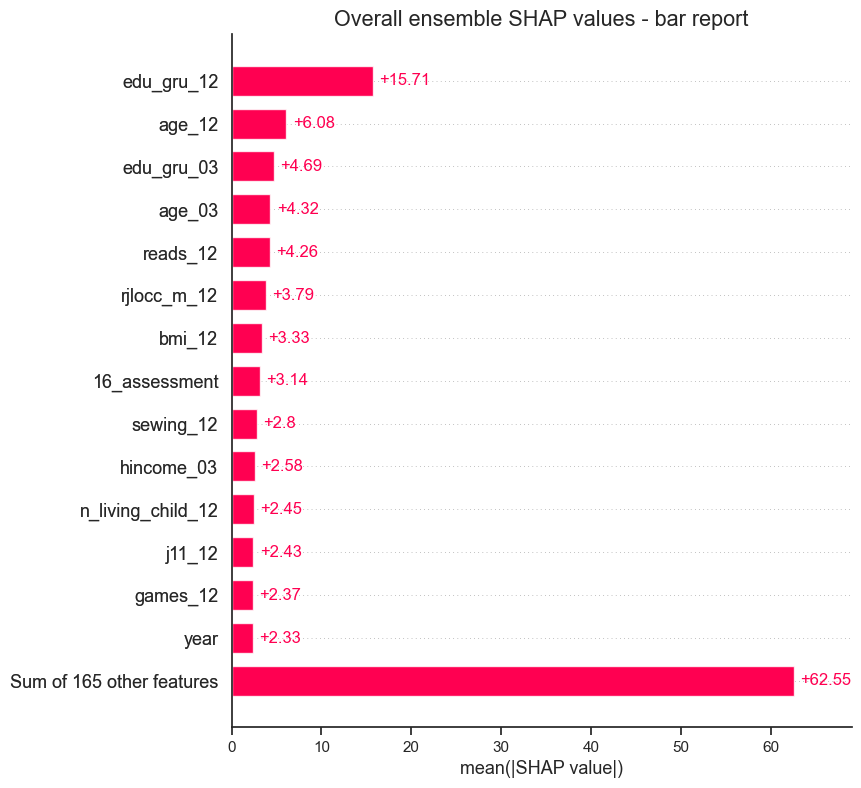

In [28]:
# Plot an overall ensemble explanation bar report

shap.plots.bar(ensemble_explanation, max_display=15, show=False)
plt.title('Overall ensemble SHAP values - bar report')
plt.show()

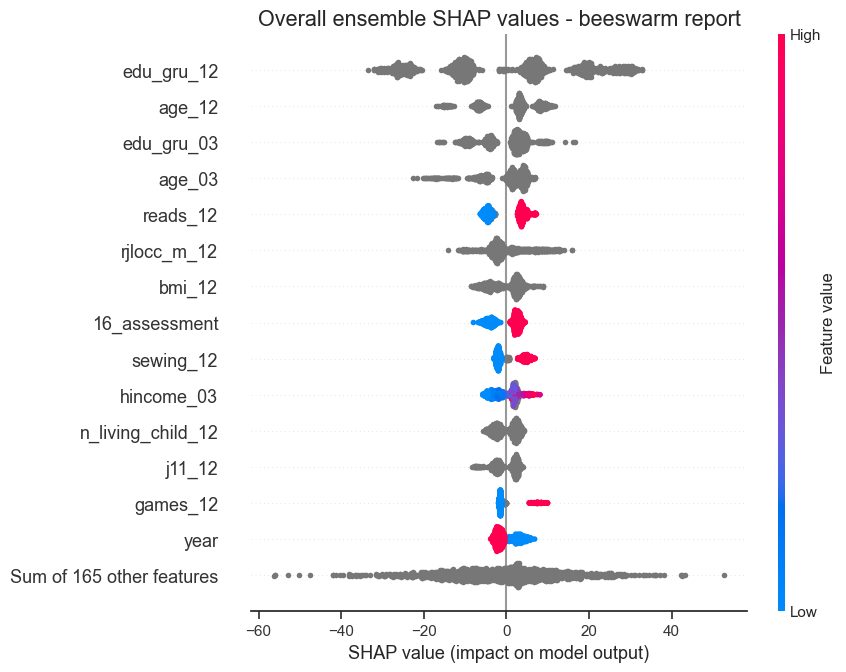

In [29]:
# Plot an overall ensemble explanation beeswarm

shap.plots.beeswarm(ensemble_explanation, max_display=15, show=False)
plt.title('Overall ensemble SHAP values - beeswarm report')
plt.show()

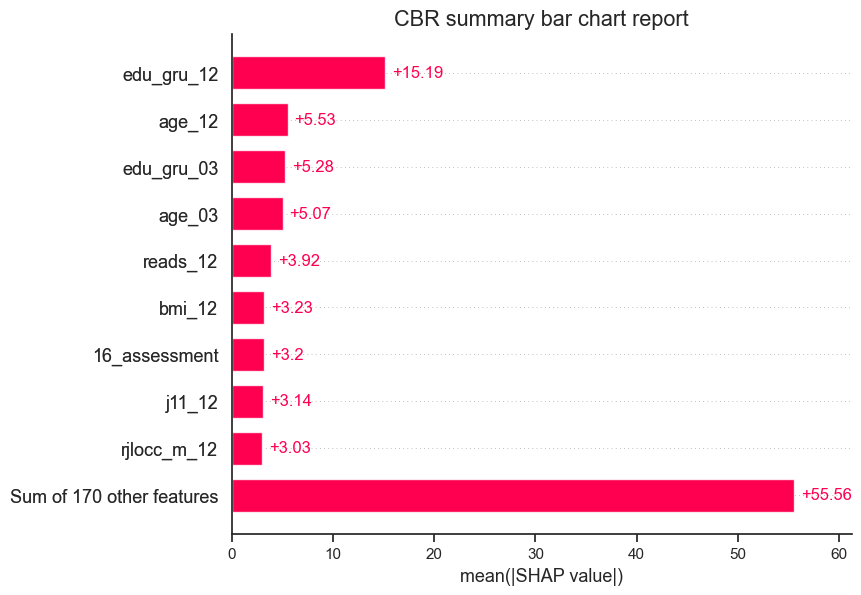

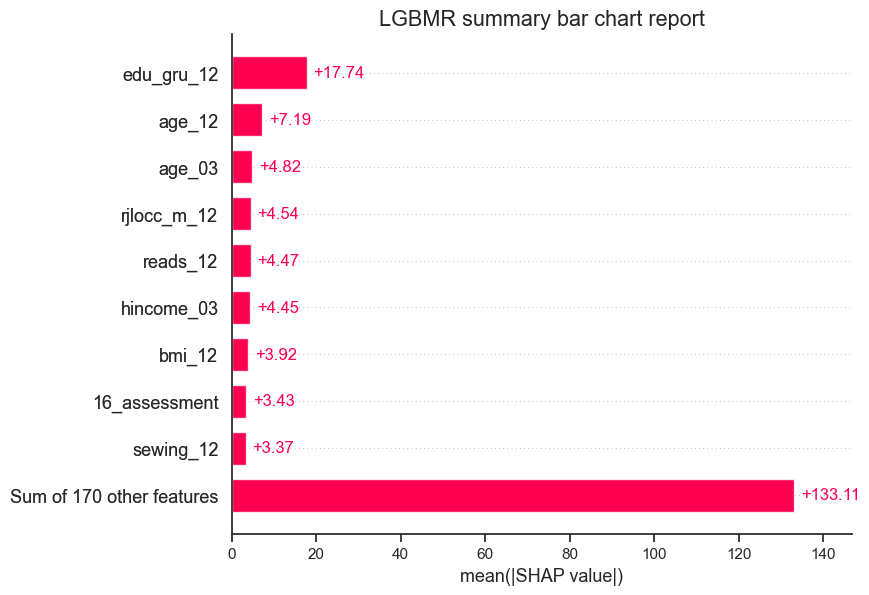

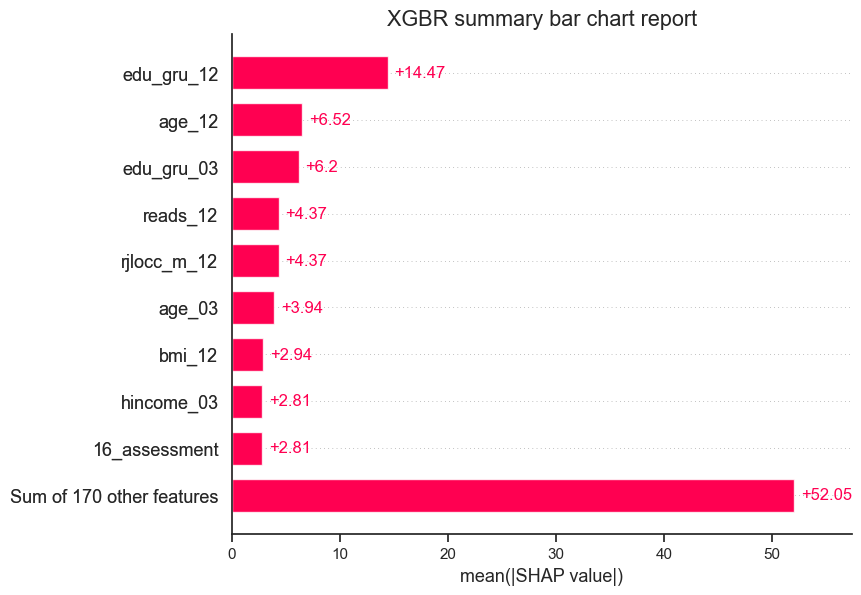

In [30]:
# See bar reports for the individual estimators

for name, explanation in subestimator_explanations.items():
    shap.plots.bar(explanation, max_display=10, show=False)
    plt.title(name.upper() + ' summary bar chart report')
    plt.show()

### Individual predictions

In [32]:
# See ensemble shap values for particular samples - here the first few

pd.DataFrame(ensemble_explanation.values[0:4], columns=ensemble_explanation.feature_names)

,age_03,urban_03,married_03,n_mar_03,edu_gru_03,n_living_child_03,migration_03,glob_hlth_03,adl_dress_03,adl_walk_03,...,rrfcntx_m_12,rsocact_m_12,rrelgwk_12,a34_12,j11_12,16_assessment,21_assessment,03_survey,12_survey,year
0,1.168646,0.107696,0.356719,-0.155484,4.281380,1.381215,-0.391362,-0.153696,-0.012183,0.010479,...,1.014997,0.304917,-0.349819,0.158136,3.154762,1.454786,-13.325939,0.030493,0.0,2.345564
1,1.943999,0.003360,0.257403,-0.043294,4.513185,1.067762,-0.309754,-0.148416,0.007145,-0.009860,...,-3.783954,-2.904955,0.223554,0.325337,-3.995444,2.893529,1.454162,0.025972,0.0,2.863633
2,2.010205,0.025627,0.272309,-0.043294,4.621844,1.091578,-0.309236,-0.021385,0.007357,-0.009896,...,-3.292141,-2.693354,0.240316,0.324966,-3.761605,2.861748,1.192005,0.025972,0.0,-1.604404
3,1.200899,0.134407,0.241045,-0.027312,4.410487,1.086316,-0.389909,-0.245082,0.035560,0.023232,...,-2.030386,1.792237,0.086169,0.478688,2.263119,2.668782,1.343741,0.032466,0.0,4.153631
